# Make Figures for Fast Formation Model vs. Experiment

2024/06/13

Make clear plots of the formation data focusing on thickness expansion

Andrew Weng

In [1]:
import os, sys

# Move the path up a level to be able to index into source files
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('../')
    sys.path.insert(0, 'src/')

from src import cellsim as cellsim

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy.signal import savgol_filter
from src import plotter as plotter

%load_ext autoreload

plotter.initialize(plt)

target_dir = os.getcwd()

# Load the Experimental Data

In [2]:
def fetch_file_list(cellid):

    target_dir_arbin = f'{target_dir}/data/raw/from-voltaiq'


    if cellid == 152064:
        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152064_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
                        ]

        daq_channel = 'Key_CH1'

        hr_max = 20*24

    elif cellid == 152074: # BASELINE FORMATION (repeat 2)

        file_arbin_list = [
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMBASE_1_P45C_5P0PSI_20220902_R1.csv',
        f'{target_dir_arbin}/UMBL2022FEB_CELL152074_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv'
                        ]

        daq_channel = 'Key_CH0'

        hr_max = 20*24

    elif cellid == 152071: # FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMFAST_1_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152071_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH3'

        hr_max = 20*24

    elif cellid == 152098: # SUPER FAST FORMATION

        file_arbin_list = [
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMTAP_2_P45C_5P0PSI_20220901_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMFAST_2_P45C_5P0PSI_20220902_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_FORMAGING_1_P45C_5P0PSI_20220909_R1.csv',
            f'{target_dir_arbin}/UMBL2022FEB_CELL152098_CYC_1C1CR1_P45C_5P0PSI_20220923_R1.csv'
        ]

        daq_channel = 'Key_CH2'

        hr_max = 20*24


    return file_arbin_list, daq_channel, hr_max


In [3]:
def fetch_experimental_data(cellid, max_hours=1000000):

    # To make the dQ/dV plot work, be sure to only select the FORM protocol without
    # including the aging file. Otherwise the time vector will be confused.
    file_indices_to_include = np.array([1,2])

    file_arbin_list, daq_channel, hr_max = fetch_file_list(cellid)


    # Load the Arbin Data
    df_arbin_list = []

    for file in np.array(file_arbin_list)[file_indices_to_include]:

        df = pd.read_csv(file)
        df['Timestamp'] = pd.to_datetime(df['Timestamp'])
        df['Timestamp']= df['Timestamp'].apply(lambda x : x.tz_localize(None))
        df_arbin_list.append(df)

    df_arbin = pd.concat(df_arbin_list, axis=0)

    # Filter the Arbin Data
    qq = df_arbin['Charge Capacity (Ah)']
    tv = df_arbin['Timestamp'].astype(int)
    tv = (tv - np.min(tv)) / 1e9
    y_voltage = df_arbin['Potential (V)']
    y_current = df_arbin['Current (A)']

    y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
    y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN

    # Load the Keyence data
    file_keyence = f'{target_dir}/data/raw/from-keyence/keyence_20220901_213928.csv'
    df_keyence = pd.read_csv(file_keyence)
    df_keyence['computer time'] = pd.to_datetime(df_keyence['computer time'], unit='s')
    df_keyence['computer time'] = df_keyence['computer time'].apply(lambda x : x.tz_localize(None))

    # Filter the Keyence data
    df_keyence = df_keyence.loc[(df_keyence['computer time'] > df_arbin['Timestamp'].iloc[0]) & \
                                (df_keyence['computer time'] < df_arbin['Timestamp'].iloc[-1])]
    y_strain = df_keyence[daq_channel] - df_keyence[daq_channel].iloc[0]
    y_strain[y_strain > 500] = np.NaN

    tt = df_keyence['computer time'].astype(int)
    tt = (tt - np.min(tt)) / 1e9

    y_strain.iloc[np.where(tt/3600 > hr_max)] = np.NaN

    out = dict()

    idx = np.where(tv < max_hours*3600)[0]
    out['arbin_time'] = tv.iloc[idx]
    out['arbin_voltage'] = y_voltage.iloc[idx]
    out['arbin_current'] = y_current.iloc[idx]

    idx = np.where(tt < max_hours * 3600)[0]
    out['daq_time'] = tt.iloc[idx]
    out['daq_strain'] = y_strain.iloc[idx]

    return out


# Load the experimental data

In [4]:
expt1 = fetch_experimental_data(152064)
expt2 = fetch_experimental_data(152074)
expt3 = fetch_experimental_data(152071, 16)
expt4 = fetch_experimental_data(152098, 7)

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_29189/704863275.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_voltage.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_29189/704863275.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_current.iloc[np.where(tv/3600 > hr_max)] = np.NaN
/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_29189/704863275.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guid

# Plot the experimental data

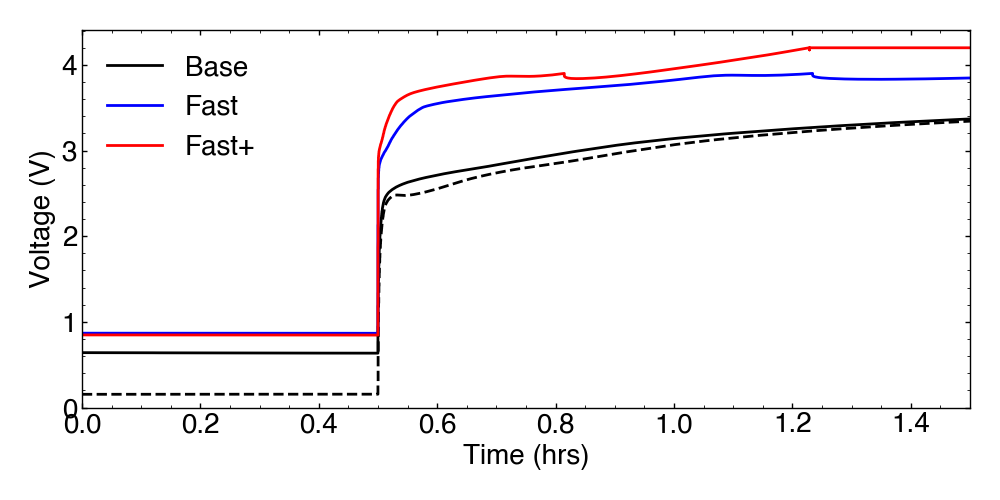

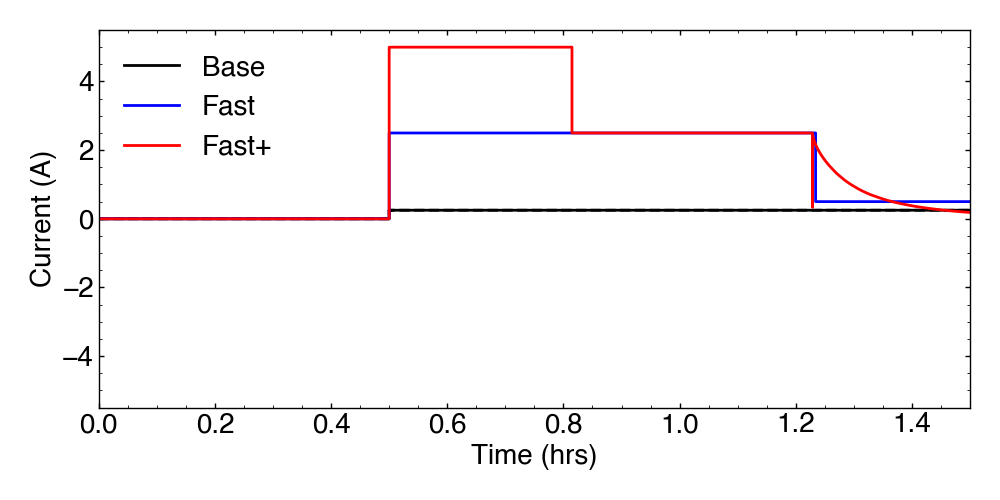

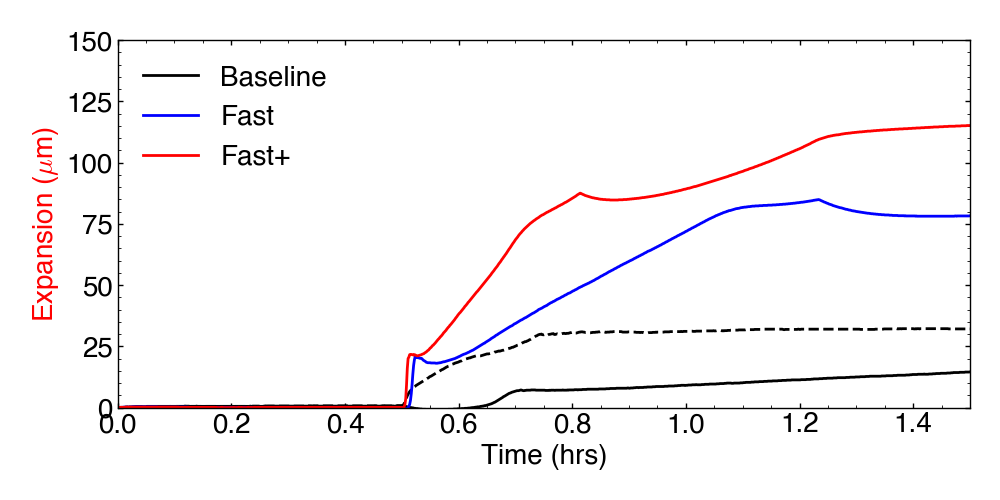

In [5]:
%matplotlib widget

XLIM = (-0.1 * 24, 2.85 * 24)
XLIM = (0, 1.5)
# The voltage plot
plt.figure(figsize=(10,5))
ax1 = plt.gca()

ax1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label='Base')
ax1.plot(expt2['arbin_time']/3600, expt2['arbin_voltage'], color='k', ls='--', label='')
ax1.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label='Fast')
ax1.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+')
ax1.set_xlabel('Time (hrs)')
ax1.set_ylabel('Voltage (V)')
ax1.set_ylim(bottom=0)
ax1.legend()
ax1.grid(False)
ax1.set_xlim(XLIM)

# The current plot
plt.figure(figsize=(10,5))
ax2 = plt.gca()

ax2.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax2.plot(expt2['arbin_time']/3600, expt2['arbin_current'], color='k', ls='--', label='')
ax2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax2.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax2.set_xlabel('Time (hrs)')
ax2.set_ylabel('Current (A)')
ax2.legend()
ax2.grid(False)
ax2.set_xlim(XLIM)

# The expansion plot
plt.figure(figsize=(10,5))
ax3 = plt.gca()
ax3.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label='Baseline')
ax3.plot(expt2['daq_time']/3600, expt2['daq_strain'], color='k', ls='--', label='')
ax3.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label='Fast')
ax3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+')
ax3.legend()
ax3.set_ylabel(r'Expansion ($\mu$m)')
ax3.yaxis.label.set_color('red')
ax3.set_ylim(bottom=0, top=150)
ax3.set_xlim(XLIM)
ax3.set_xlabel('Time (hrs)')
ax3.grid(False)

# Run the simulation: baseline formation

In [6]:
%autoreload
Ichg = 2.5/10  # A
Idch = -2.5/10 # A
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')
tag = cell.get_tag()

# sim = cellsim.Simulation(cell, 520*3600)
sim1 = cellsim.Simulation(cell, 26*20*3600)

# Formation
import time
sim1.run_rest(1, rest_time_hrs=0.5)
sim1.run_chg_cccv(2, 2.5/10, Icv, vmax)
sim1.run_dch_cccv(2, Idch, Idch, vmin)
sim1.run_chg_cccv(3, 2.5/10, Icv, vmax)
sim1.run_dch_cccv(3, Idch, Idch, vmin)
sim1.run_chg_cccv(4, 2.5/10, Icv, vmax)
sim1.run_dch_cccv(4, Idch, 0.05, vmin)
sim1.run_rest(4, rest_time_hrs=6)

sim1_time1 = sim1.get_results()['t'].iloc[-1]/3600

# RPT
sim1.run_chg_cccv(5, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim1.run_dch_cccv(5, -2.5/20, Icv, vmin)
sim1.run_chg_cccv(6, +2.5/20, Icv, vmax)
sim1.run_rest(6, rest_time_hrs=14)
sim1.run_dch_cccv(7, -2.5/2, -2.5/2, vmin)
sim1.run_rest(7, rest_time_hrs=19)

# Aging
sim1.run_chg_cccv(8, 2.5/2, 2.5/2, vmax)
sim1.run_rest(8, rest_time_hrs=7*24)
sim1.run_dch_cccv(8, -2.5/20, -2.5/20, vmin)

sim1_time2 = sim1.get_results()['t'].iloc[-1]/3600

# Cycling

for i in np.arange(9, 20):
    sim1.run_chg_cccv(i, 2.5, 2.5, vmax)
    sim1.run_dch_cccv(i, -2.5, -2.5, vmin)

df_sim1 = sim1.get_results()

sim1_time3 = df_sim1['t'].iloc[-1]/3600


Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Discharge to 3.0V...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Discharge to 3.0V...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Discharge to 3.0V...
Running Cyc4: Rest for 6 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Charge to 4.2V...
Running Cyc6: Rest for 14 hours...
Running Cyc7: Discharge to 3.0V...
Running Cyc7: Rest for 19 hours...
Running Cyc8: Charge to 4.2V...
Running Cyc8: Rest for 168 hours...
Running Cyc8: Discharge to 3.0V...
Running Cyc9: Charge to 4.2V...
Running Cyc9: Discharge to 3.0V...
Running Cyc10: Charge to 4.2V...
Running Cyc10: Discharge to 3.0V...
Running Cyc11: Charge to 4.2V...
Running Cyc11: Discharge to 3.0V...
Running Cyc12: Charge to 4.2V...
Running Cyc12: Discharge to 3.0V...
Running Cyc13: Charge to 4.2V...
Running Cyc13: Discharge to 3.0V...
Running Cyc14: Charge to 4.2V...
Running Cyc14: Discharge to 3.0V...
Running Cy

In [7]:
# Get the results from sim1
results = sim1.get_results()

# Create a DataFrame with the resistance values
df_resistance = pd.DataFrame({
    'R_sei (total)': results['R_sei'],
    'R_sei1 (EC)': results['R_sei1'],
    'R_sei2 (VC)': results['R_sei2'],
    'Delta_sei1' : results['delta_sei1'],
    'Delta_sei2' : results['delta_sei2'],
    'kappa_sei1': results['kappa_sei1'],
    'kappa_sei2': results['kappa_sei2']
})

# Display the first few rows
print("SEI Resistance Values (Ohms):")
print(df_resistance.head(1000))

# You can also get some statistics
print("\nSummary Statistics:")
print(df_resistance.describe())

SEI Resistance Values (Ohms):
     R_sei (total)  R_sei1 (EC)  R_sei2 (VC)    Delta_sei1    Delta_sei2  \
0         0.000749     0.000466     0.000283  2.500000e-09  2.500000e-09   
1         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
2         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
3         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
4         0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
..             ...          ...          ...           ...           ...   
995       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
996       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
997       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
998       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   
999       0.000005     0.000003     0.000002  2.500000e-09  2.500000e-09   

       kappa_sei1    kappa_sei2  
0    6.540937e-09  1.07

/Users/aweng/code/formation-modeling/src/cellsim.py:1033: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/{fig_name}.png',
/Users/aweng/code/formation-modeling/venv/lib/python3.8/site-packages/ipympl/backend_nbagg.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


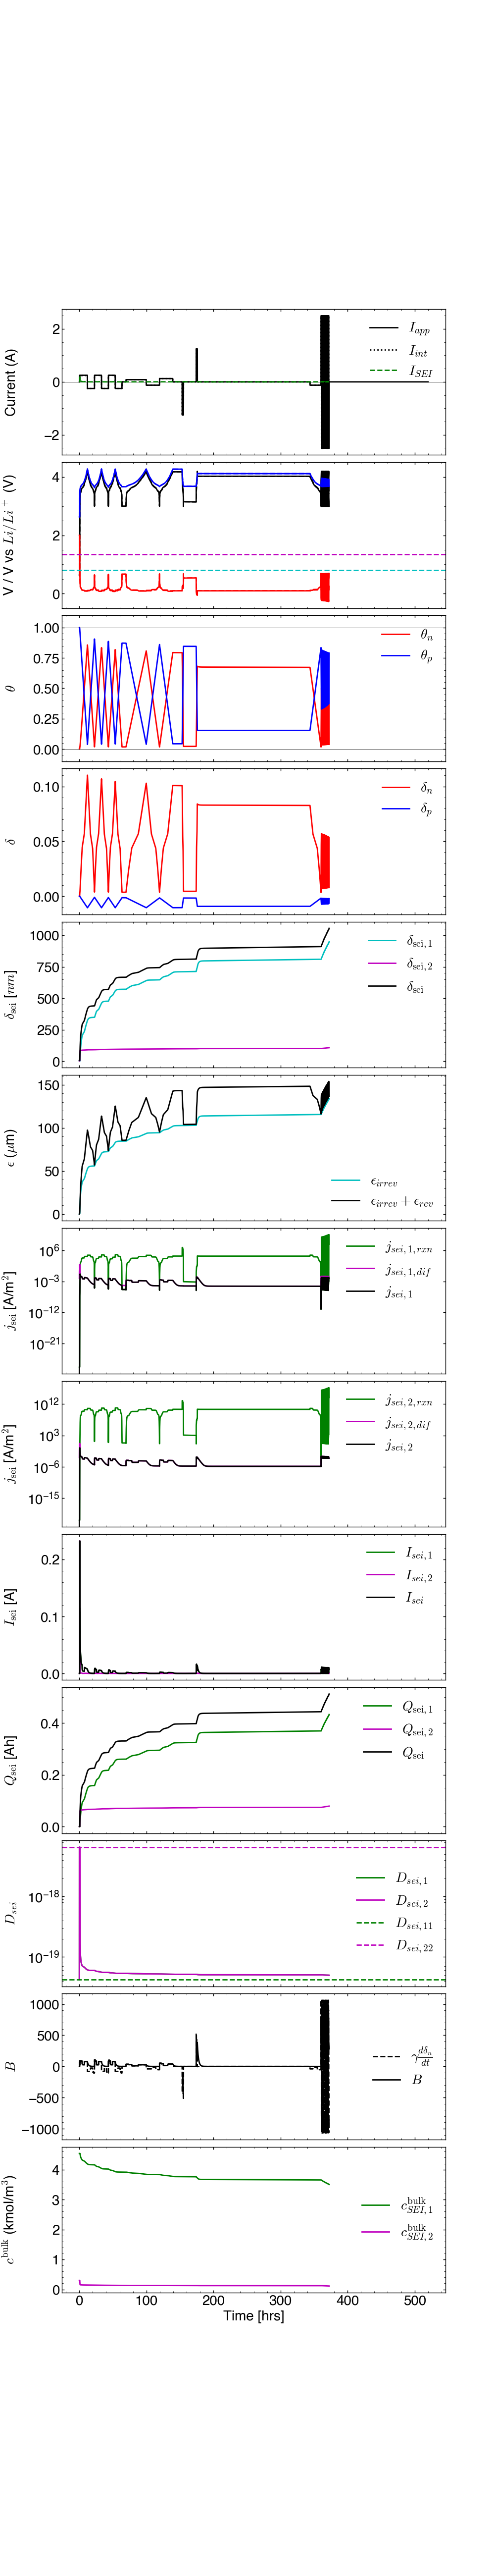

In [8]:

# %matplotlib widget
sim1.plot()


# Run the simulation: fast formation

In [9]:
%autoreload
Ichg = 2.5/10  # A
Idch = -2.5/10 # A
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')
tag = cell.get_tag()

# sim = cellsim.Simulation(cell, 520*3600)
sim2 = cellsim.Simulation(cell, 26*20*3600)

# Formation
sim2.run_rest(1, rest_time_hrs=0.5)
sim2.run_chg_cccv(2, 2.5, 2.5, 3.9)
sim2.run_chg_cccv(2, 2.5/5, 0.125, 4.2)
sim2.run_rest(2, rest_time_hrs=1/6)
sim2.run_dch_cccv(2, -2.5/5, 2.5/5, 3.9)
sim2.run_rest(2, rest_time_hrs=1/6)
sim2.run_chg_cccv(3, 2.5/5, 0.125, 4.2)
sim2.run_rest(3, rest_time_hrs=1/6)
sim2.run_dch_cccv(3, -2.5/5, 2.5/5, 3.9)
sim2.run_rest(3, rest_time_hrs=1/6)
sim2.run_chg_cccv(4, 2.5/5, 0.125, 4.2)
sim2.run_rest(4, rest_time_hrs=1/6)
sim2.run_dch_cccv(4, -2.5/5, 2.5/5, 3.9)
sim2.run_rest(4, rest_time_hrs=1/6)
sim2.run_chg_cccv(5, 2.5/5, 0.125, 4.2)
sim2.run_rest(5, rest_time_hrs=1/6)
sim2.run_dch_cccv(5, -2.5/5, 2.5/5, 3.9)
sim2.run_dch_cccv(5, -2.5/1, 0.05, 3.0)
sim2.run_rest(6, rest_time_hrs=3)

sim2_time1 = sim2.get_results()['t'].iloc[-1]/3600

# RPT
sim2.run_chg_cccv(7, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim2.run_dch_cccv(7, -2.5/20, Icv, vmin)
sim2.run_chg_cccv(8, +2.5/20, Icv, vmax)
sim2.run_rest(8, rest_time_hrs=14)
sim2.run_dch_cccv(9, -2.5/2, -2.5/2, vmin)
sim2.run_rest(9, rest_time_hrs=19)

# Aging
sim2.run_chg_cccv(10, 2.5/2, 2.5/2, vmax)
sim2.run_rest(10, rest_time_hrs=7*24)
sim2.run_dch_cccv(10, -2.5/20, -2.5/20, vmin)

sim2_time2 = sim2.get_results()['t'].iloc[-1]/3600
# Cycling

for i in np.arange(11, 20):
    sim2.run_chg_cccv(i, 2.5, 2.5, vmax)
    sim2.run_dch_cccv(i, -2.5, -2.5, vmin)

df_sim2 = sim2.get_results()

sim2_time3 = df_sim2['t'].iloc[-1]/3600


Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc5: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc7: Charge to 4.2V...
Running Cyc7: Discharge to 3.0V...
Running Cyc8: Charge to 4.2V...
Running Cyc8: Rest for 14 hours...
Running Cyc9: Discharge to 3.0V...
Running Cyc9: Rest for 19 hours...
Running Cyc10: Charge to 4.

/Users/aweng/code/formation-modeling/src/cellsim.py:1033: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/{fig_name}.png',
/Users/aweng/code/formation-modeling/venv/lib/python3.8/site-packages/ipympl/backend_nbagg.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


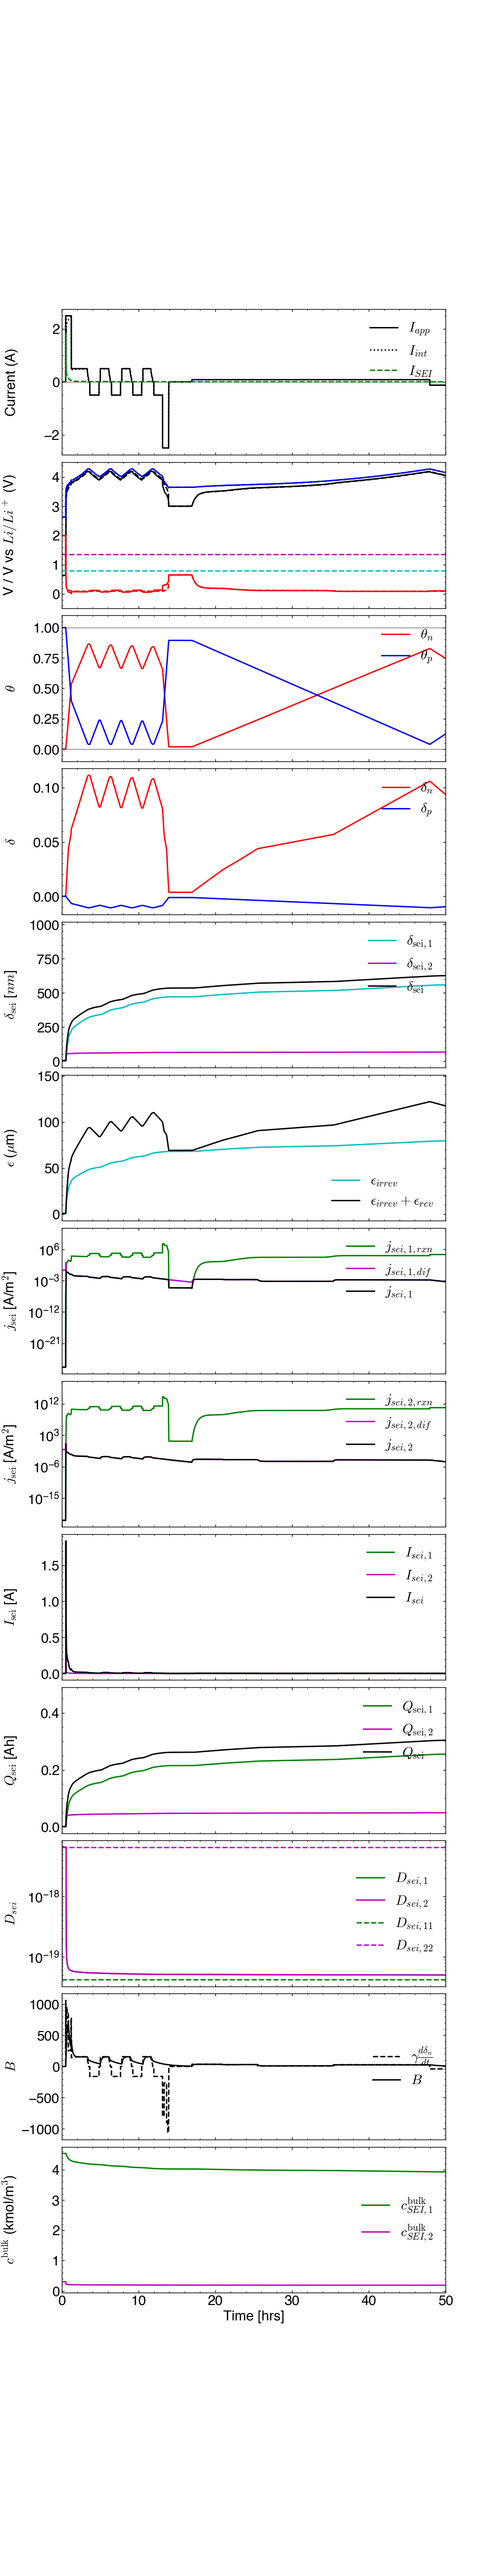

In [10]:
%matplotlib widget
sim2.plot(xlims=(0,50))


# Running the simulation: Fast+ Formation

In [11]:
%autoreload
Icv = 2.5/20   # A

vmax = 4.2
vmin = 3.0

cell = cellsim.Cell()
cell.load_config('params/default.yaml')
tag = cell.get_tag()

# sim = cellsim.Simulation(cell, 520*3600)
sim3 = cellsim.Simulation(cell, 26*20*3600)

# Formation
sim3.run_rest(1, rest_time_hrs=0.5)
sim3.run_chg_cccv(2, 5.0, 5.0, 3.9)
sim3.run_chg_cccv(2, 2.5, 0.125, 4.2)
sim3.run_rest(2, rest_time_hrs=1/6)
sim3.run_dch_cccv(2, -2.5, 2.5, 3.9)
sim3.run_rest(2, rest_time_hrs=1/6)
sim3.run_chg_cccv(3, 2.5, 0.125, 4.2)
sim3.run_rest(3, rest_time_hrs=1/6)
sim3.run_dch_cccv(3, -2.5, 2.5, 3.9)
sim3.run_rest(3, rest_time_hrs=1/6)
sim3.run_chg_cccv(4, 2.5, 0.125, 4.2)
sim3.run_rest(4, rest_time_hrs=1/6)
sim3.run_dch_cccv(4, -2.5, 2.5, 3.9)
sim3.run_rest(4, rest_time_hrs=1/6)
sim3.run_chg_cccv(5, 2.5, 2.5, 4.2)
sim3.run_rest(2, rest_time_hrs=1/6)
sim3.run_dch_cccv(5, -2.5, 2.5, 3.9)
sim3.run_dch_cccv(5, -5.0, 0.05, 3.0)
sim3.run_rest(6, rest_time_hrs=3)

sim3_time1 = sim3.get_results()['t'].iloc[-1]/3600

# RPT
sim3.run_chg_cccv(7, +2.5/30, +2.5/30, vmax) # Approximate HPPC Pulse Charge
sim3.run_dch_cccv(7, -2.5/20, Icv, vmin)
sim3.run_chg_cccv(8, +2.5/20, Icv, vmax)
sim3.run_rest(8, rest_time_hrs=14)
sim3.run_dch_cccv(9, -2.5/2, -2.5/2, vmin)
sim3.run_rest(9, rest_time_hrs=19)

# Aging
sim3.run_chg_cccv(10, 2.5/2, 2.5/2, vmax)
sim3.run_rest(10, rest_time_hrs=7*24)
sim3.run_dch_cccv(10, -2.5/20, -2.5/20, vmin)

sim3_time2 = sim3.get_results()['t'].iloc[-1]/3600

# Cycling
for i in np.arange(11, 20):
    sim3.run_chg_cccv(i, 2.5, 2.5, vmax)
    sim3.run_dch_cccv(i, -2.5, -2.5, vmin)

df_sim3 = sim3.get_results()

sim3_time3 = df_sim3['t'].iloc[-1]/3600

Running Cyc1: Rest for 0.5 hours...
Running Cyc2: Charge to 3.9V...
Running Cyc2: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc2: Discharge to 3.9V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc3: Charge to 4.2V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc3: Discharge to 3.9V...
Running Cyc3: Rest for 0.16666666666666666 hours...
Running Cyc4: Charge to 4.2V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc4: Discharge to 3.9V...
Running Cyc4: Rest for 0.16666666666666666 hours...
Running Cyc5: Charge to 4.2V...
Running Cyc2: Rest for 0.16666666666666666 hours...
Running Cyc5: Discharge to 3.9V...
Running Cyc5: Discharge to 3.0V...
Running Cyc6: Rest for 3 hours...
Running Cyc7: Charge to 4.2V...
Running Cyc7: Discharge to 3.0V...
Running Cyc8: Charge to 4.2V...
Running Cyc8: Rest for 14 hours...
Running Cyc9: Discharge to 3.0V...
Running Cyc9: Rest for 19 hours...
Running Cyc10: Charge to 4.

/Users/aweng/code/formation-modeling/src/cellsim.py:1033: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/{fig_name}.png',
/Users/aweng/code/formation-modeling/venv/lib/python3.8/site-packages/ipympl/backend_nbagg.py:336: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  self.figure.savefig(buf, format='png', dpi='figure')


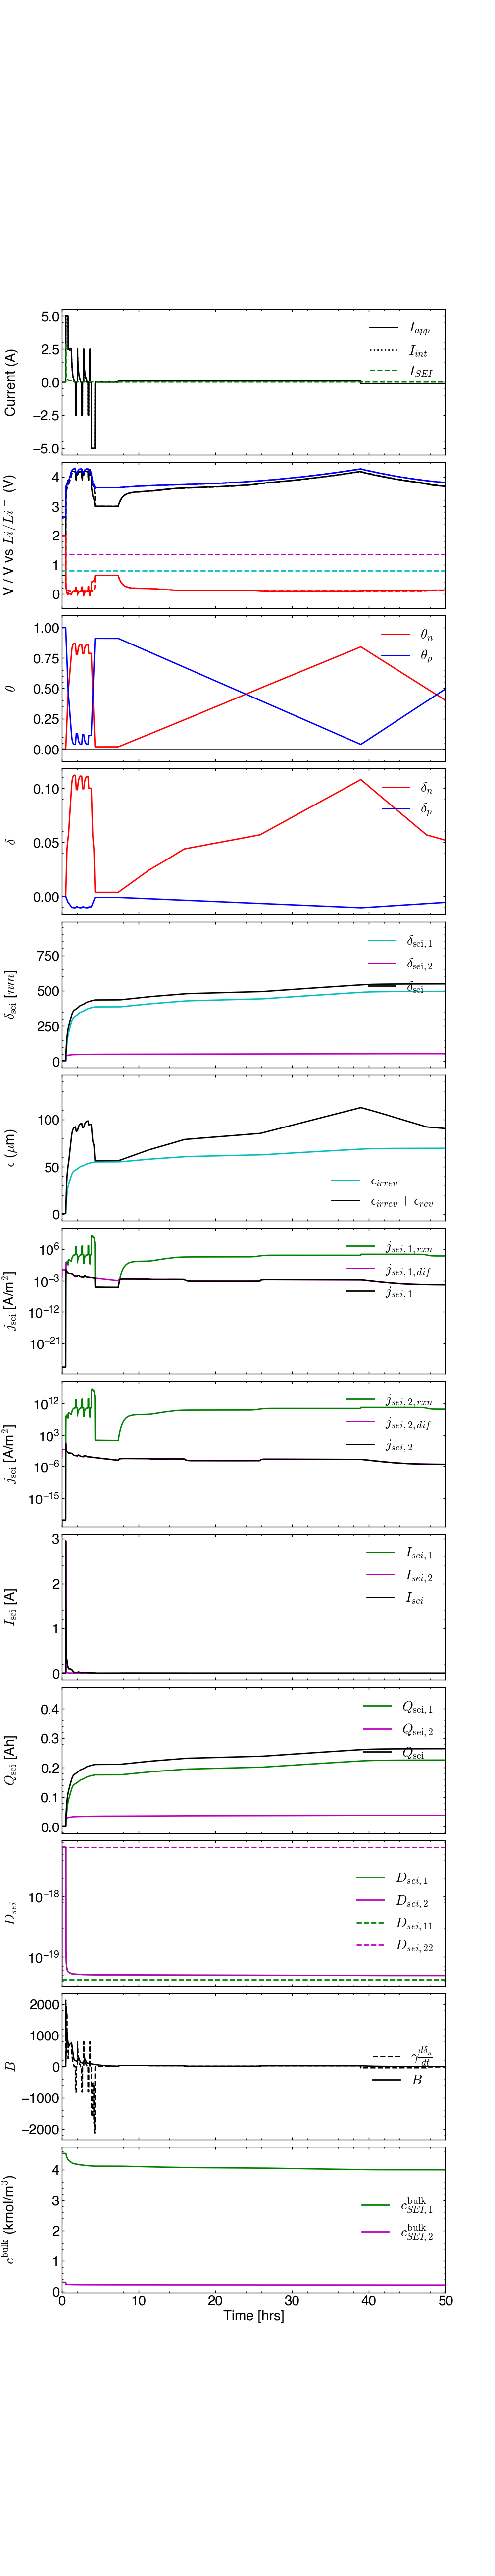

In [12]:
%matplotlib widget
sim3.plot(xlims=(0,50))

# Compare Voltages: Baseline Formation

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_29189/893605971.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/fig_validation_{tag}.png', dpi=200)


Text(0, 0.5, 'Current (A)')

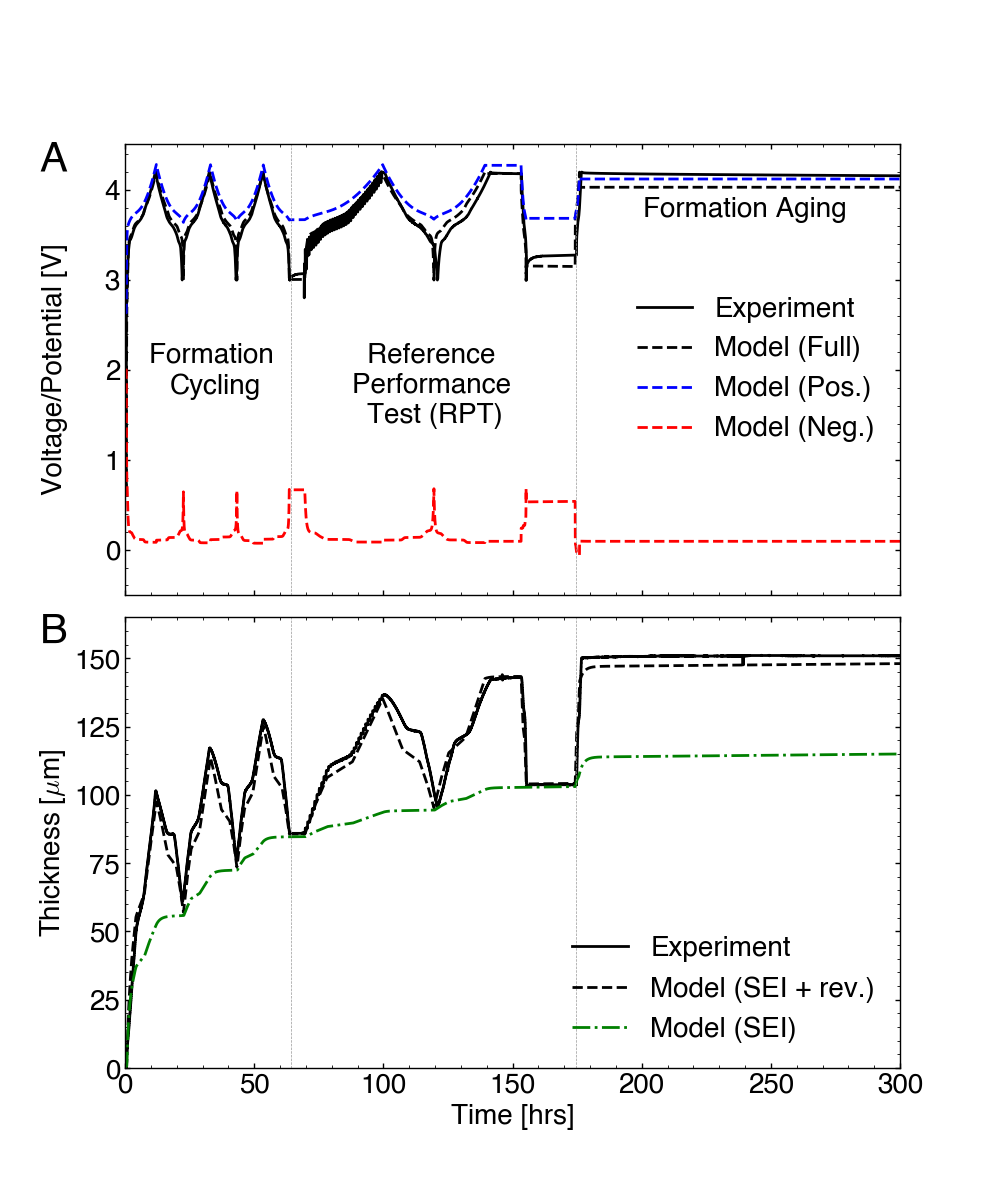

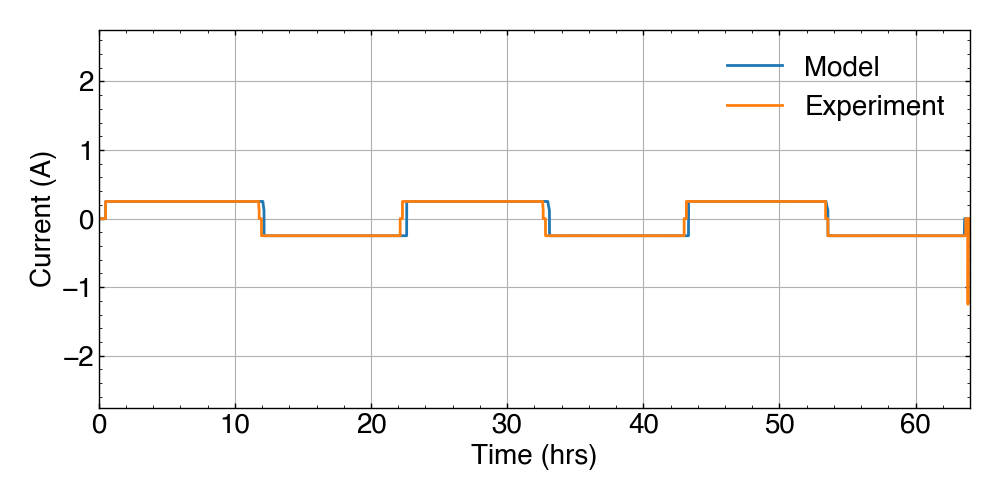

In [13]:
exp_sim = df_sim1['expansion_rev'] + df_sim1['expansion_irrev']
v_sim = df_sim1['vt']
t_sim = df_sim1['t']

gridspec = dict(hspace=0.05, height_ratios=[1,1])

fig, axs = plt.subplots(nrows=2, ncols=1,
                        figsize=(10,12),
                        gridspec_kw=gridspec,
                        sharex=True)

axs[0].grid(False)
axs[0].plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], c='k', lw=2, label='Experiment')
axs[0].plot(t_sim/3600, df_sim1['vt'], c='k', ls='--', lw=2, label='Model (Full)')
axs[0].plot(t_sim/3600, df_sim1['ocv_p'] + df_sim1['eta_p'], c='b', ls='--', lw=2, label='Model (Pos.)')
axs[0].plot(t_sim/3600, df_sim1['ocv_n'] - df_sim1['eta_n'], c='r', ls='--', lw=2, label='Model (Neg.)')
axs[0].legend(loc='right', fontsize=20)
# axs[0].set_xlabel('Time (hrs)')
axs[0].set_ylabel('Voltage/Potential [V]')
axs[0].set_xlim((0, 300))

axs[1].grid(False)
axs[1].plot(expt1['daq_time']/3600, expt1['daq_strain'], c='k', lw=2, label='Experiment')
axs[1].plot(t_sim/3600, (df_sim1['expansion_rev'] + df_sim1['expansion_irrev'])*1e6, c='k', lw=2, ls='--', label='Model (SEI + rev.)')
axs[1].plot(t_sim/3600, (df_sim1['expansion_irrev'])*1e6, c='g', ls='-.', lw=2, label='Model (SEI)')
axs[1].legend(loc='lower right', fontsize=20)
axs[1].set_xlabel('Time [hrs]')
axs[1].set_ylabel('Thickness [$\mu$m]')
axs[1].set_ylim((0, 165))
axs[1].set_xlim((0, 300))

# Add guidelines
[ax.axvline(x=64.35, c=(0.6, 0.6, 0.6), linestyle='--', linewidth=0.5) for ax in axs]
[ax.axvline(x=174.5, c=(0.6, 0.6, 0.6), linestyle='--', linewidth=0.5) for ax in axs]

# Add text
axs[0].text(35, 2.3, 'Formation \nCycling', horizontalalignment='center', verticalalignment='top')
axs[0].text(120, 2.3, 'Reference \nPerformance \nTest (RPT)', horizontalalignment='center', verticalalignment='top')
axs[0].text(240, 3.7, 'Formation Aging', horizontalalignment='center')

# Add subplot identifers
axs[0].text(-0.11, 0.94, 'A', transform=axs[0].transAxes, fontsize=30, fontweight='bold')
axs[1].text(-0.11, 0.94, 'B', transform=axs[1].transAxes, fontsize=30, fontweight='bold')

fig.align_ylabels()

plt.savefig(f'outputs/figures/fig_validation_{tag}.png', dpi=200)

# Sanity check the currents
plt.figure(figsize=(10,5))
plt.plot(t_sim/3600, df_sim1['i_app'], label='Model')
plt.plot(expt1['arbin_time']/3600, expt1['arbin_current'], label='Experiment')
plt.xlim((0, 64))
plt.legend()
plt.xlabel('Time (hrs)')
plt.ylabel('Current (A)')

# Compare Voltages: Fast Formation

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_29189/2609949955.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/fig_validation_{tag}.png', dpi=200)


Text(0, 0.5, 'Current (A)')

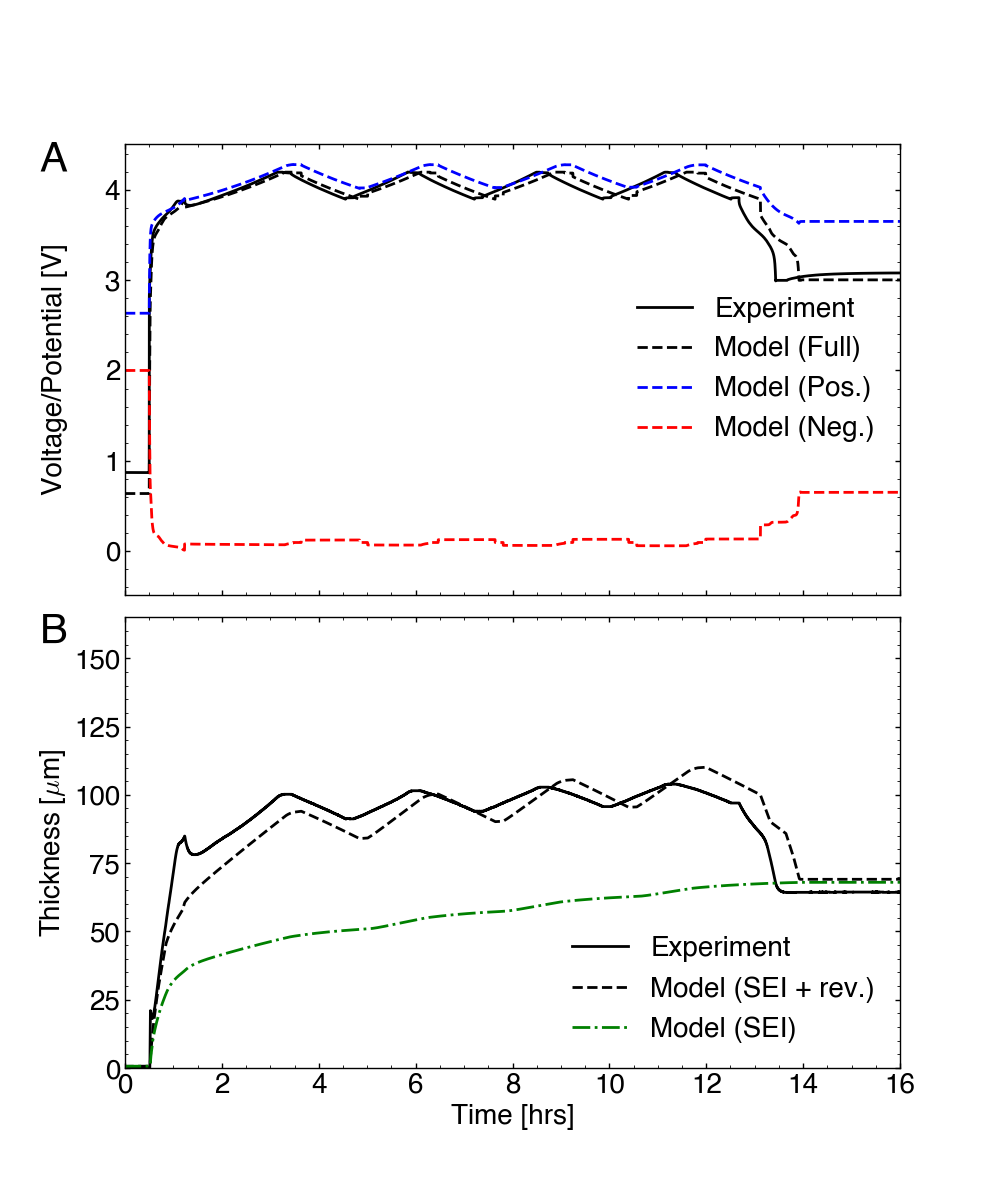

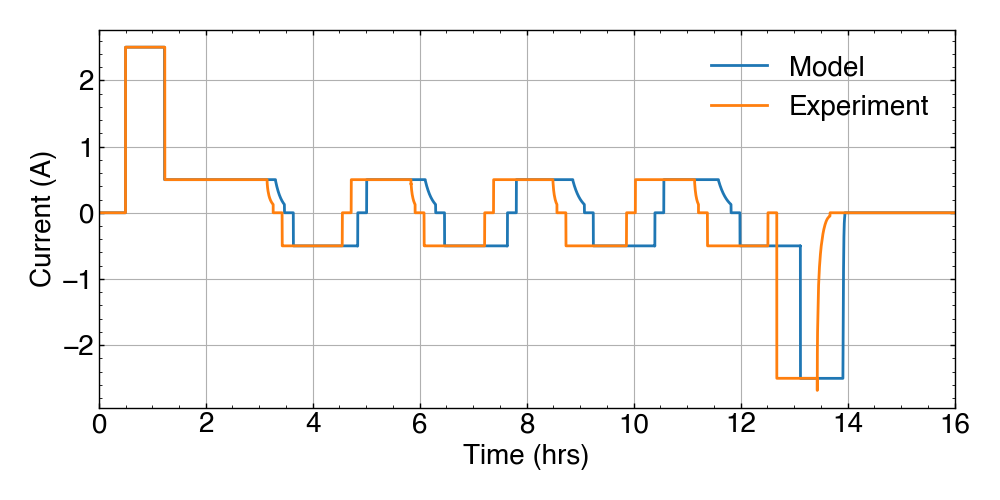

In [14]:
exp_sim = df_sim2['expansion_rev'] + df_sim2['expansion_irrev']
v_sim = df_sim2['vt']
t_sim = df_sim2['t']

XMAX = 16
gridspec = dict(hspace=0.05, height_ratios=[1,1])

fig, axs = plt.subplots(nrows=2, ncols=1,
                        figsize=(10,12),
                        gridspec_kw=gridspec,
                        sharex=True)

axs[0].grid(False)
axs[0].plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], c='k', lw=2, label='Experiment')
axs[0].plot(t_sim/3600, df_sim2['vt'], c='k', ls='--', lw=2, label='Model (Full)')
axs[0].plot(t_sim/3600, df_sim2['ocv_p'] + df_sim2['eta_p'], c='b', ls='--', lw=2, label='Model (Pos.)')
axs[0].plot(t_sim/3600, df_sim2['ocv_n'] - df_sim2['eta_n'], c='r', ls='--', lw=2, label='Model (Neg.)')
axs[0].legend(loc='right', fontsize=20)
# axs[0].set_xlabel('Time (hrs)')
axs[0].set_ylabel('Voltage/Potential [V]')
axs[0].set_xlim((0, XMAX))

axs[1].grid(False)
axs[1].plot(expt3['daq_time']/3600, expt3['daq_strain'], c='k', lw=2, label='Experiment')
axs[1].plot(t_sim/3600, (df_sim2['expansion_rev'] + df_sim2['expansion_irrev'])*1e6, c='k', lw=2, ls='--', label='Model (SEI + rev.)')
axs[1].plot(t_sim/3600, (df_sim2['expansion_irrev'])*1e6, c='g', ls='-.', lw=2, label='Model (SEI)')
axs[1].legend(loc='lower right', fontsize=20)
axs[1].set_xlabel('Time [hrs]')
axs[1].set_ylabel('Thickness [$\mu$m]')
axs[1].set_ylim((0, 165))
axs[1].set_xlim((0, XMAX))

# Add guidelines
[ax.axvline(x=64.35, c=(0.6, 0.6, 0.6), linestyle='--', linewidth=0.5) for ax in axs]
[ax.axvline(x=174.5, c=(0.6, 0.6, 0.6), linestyle='--', linewidth=0.5) for ax in axs]

# Add text
# axs[0].text(35, 2.3, 'Formation \nCycling', horizontalalignment='center', verticalalignment='top')
# axs[0].text(120, 2.3, 'Reference \nPerformance \nTest (RPT)', horizontalalignment='center', verticalalignment='top')
# axs[0].text(240, 3.7, 'Formation Aging', horizontalalignment='center')

# Add subplot identifers
axs[0].text(-0.11, 0.94, 'A', transform=axs[0].transAxes, fontsize=30, fontweight='bold')
axs[1].text(-0.11, 0.94, 'B', transform=axs[1].transAxes, fontsize=30, fontweight='bold')

fig.align_ylabels()

plt.savefig(f'outputs/figures/fig_validation_{tag}.png', dpi=200)

plt.figure(figsize=(10,5))
plt.plot(t_sim/3600, df_sim2['i_app'], label='Model')
plt.plot(expt3['arbin_time']/3600, expt3['arbin_current'], label='Experiment')
plt.xlim((0, 16))
plt.legend()
plt.xlabel('Time (hrs)')
plt.ylabel('Current (A)')

# Compare Voltages: Fast+ Formation

/var/folders/qr/bx1pzh1x6nnbdrjvw2qhqkf40000gn/T/ipykernel_29189/720652340.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.savefig(f'outputs/figures/fig_validation_{tag}.png', dpi=200)


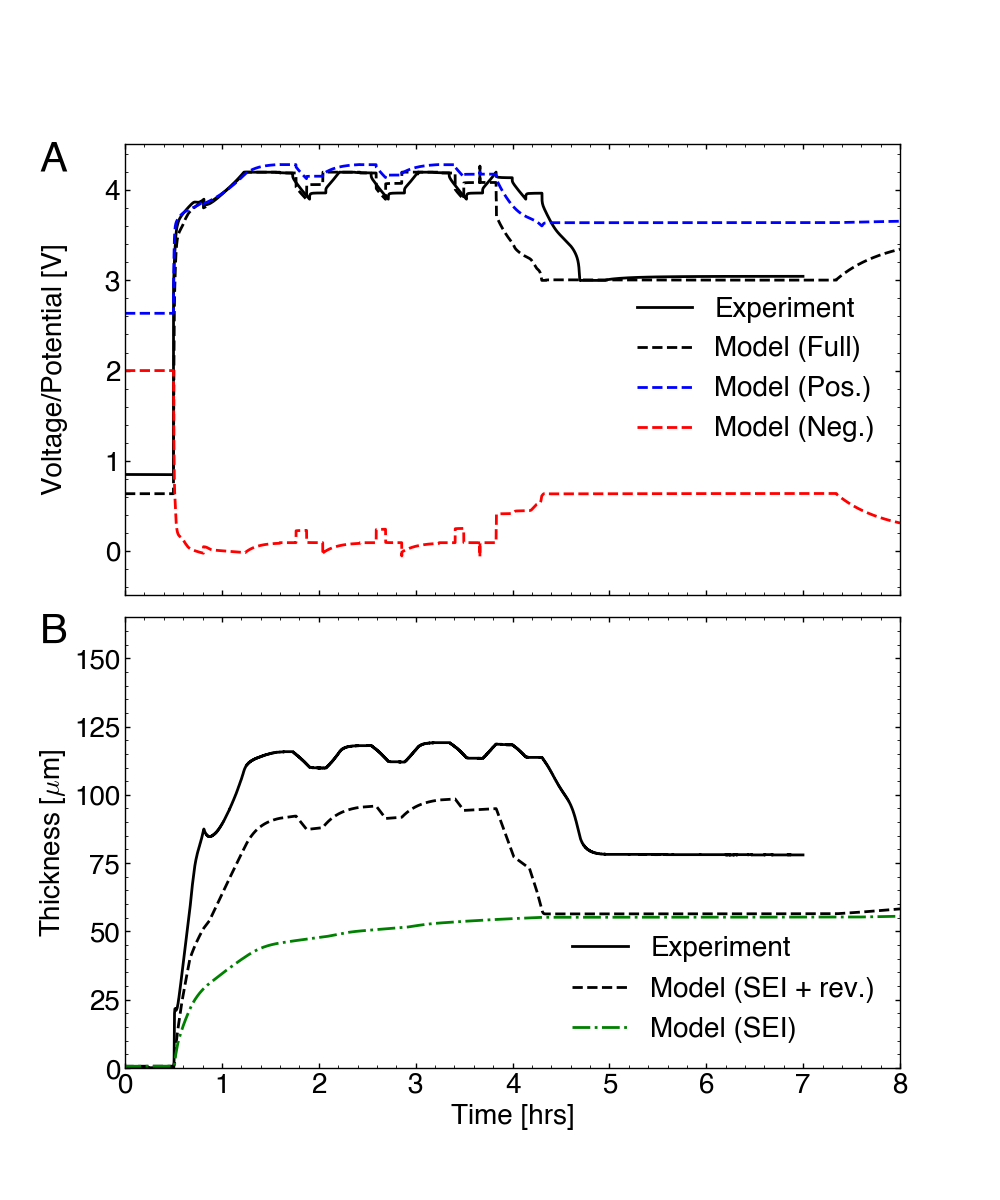

In [15]:
exp_sim = df_sim3['expansion_rev'] + df_sim3['expansion_irrev']
v_sim = df_sim3['vt']
t_sim = df_sim3['t']

XMAX = 8
gridspec = dict(hspace=0.05, height_ratios=[1,1])

fig, axs = plt.subplots(nrows=2, ncols=1,
                        figsize=(10,12),
                        gridspec_kw=gridspec,
                        sharex=True)

axs[0].grid(False)
axs[0].plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], c='k', lw=2, label='Experiment')
axs[0].plot(t_sim/3600, df_sim3['vt'], c='k', ls='--', lw=2, label='Model (Full)')
axs[0].plot(t_sim/3600, df_sim3['ocv_p'] + df_sim3['eta_p'], c='b', ls='--', lw=2, label='Model (Pos.)')
axs[0].plot(t_sim/3600, df_sim3['ocv_n'] - df_sim3['eta_n'], c='r', ls='--', lw=2, label='Model (Neg.)')
axs[0].legend(loc='right', fontsize=20)
axs[0].set_ylabel('Voltage/Potential [V]')
axs[0].set_xlim((0, XMAX))

axs[1].grid(False)
axs[1].plot(expt4['daq_time']/3600, expt4['daq_strain'], c='k', lw=2, label='Experiment')
axs[1].plot(t_sim/3600, (df_sim3['expansion_rev'] + df_sim3['expansion_irrev'])*1e6, c='k', lw=2, ls='--', label='Model (SEI + rev.)')
axs[1].plot(t_sim/3600, (df_sim3['expansion_irrev'])*1e6, c='g', ls='-.', lw=2, label='Model (SEI)')
axs[1].legend(loc='lower right', fontsize=20)
axs[1].set_xlabel('Time [hrs]')
axs[1].set_ylabel('Thickness [$\mu$m]')
axs[1].set_ylim((0, 165))
axs[1].set_xlim((0, XMAX))

# Add guidelines
[ax.axvline(x=64.35, c=(0.6, 0.6, 0.6), linestyle='--', linewidth=0.5) for ax in axs]
[ax.axvline(x=174.5, c=(0.6, 0.6, 0.6), linestyle='--', linewidth=0.5) for ax in axs]

# Add text
# axs[0].text(35, 2.3, 'Formation \nCycling', horizontalalignment='center', verticalalignment='top')
# axs[0].text(120, 2.3, 'Reference \nPerformance \nTest (RPT)', horizontalalignment='center', verticalalignment='top')
# axs[0].text(240, 3.7, 'Formation Aging', horizontalalignment='center')

# Add subplot identifers
axs[0].text(-0.11, 0.94, 'A', transform=axs[0].transAxes, fontsize=30, fontweight='bold')
axs[1].text(-0.11, 0.94, 'B', transform=axs[1].transAxes, fontsize=30, fontweight='bold')

fig.align_ylabels()

plt.savefig(f'outputs/figures/fig_validation_{tag}.png', dpi=200)

# # # # # # # Sanity check the currents
# # # # # # # plt.figure(figsize=(10,5))
# # # # # # plt.plot(t_sim/3600, df_sim3['i_app'], label='Model')
# # # # # plt.plot(expt4['arbin_time']/3600, expt4['arbin_current'], label='Experiment')
# # # # plt.xlim((0, 6))
# # # plt.legend()
# # plt.xlabel('Time (hrs)')
# plt.ylabel('Current (A)')

# Summary

Type | Duration | Thickness after form. (meas) | Thickness after form. (model) | Li consumed after form. (meas)
--- | --- | --- | --- | ---
Base (1) | 64 hrs | 85.9 um | 86.4 um | ? Ah
Base (2) | 64 hrs | 89.0 um | 86.4 um | ? Ah
Fast | 14 hrs | 64.4 um | 73.6 um | ? Ah
Fast+ | 5 hrs | 78.2 um | 74.2 um | ? Ah


# Overlay all experimental and model data

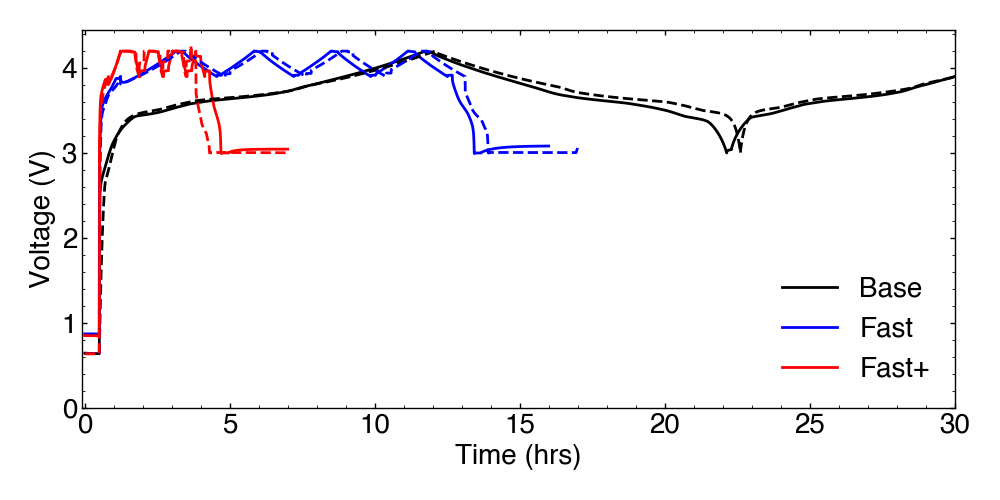

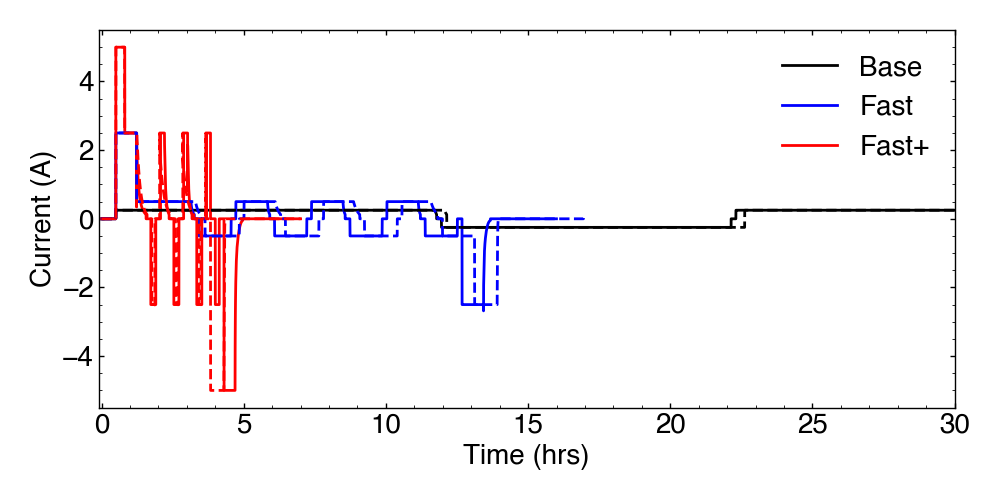

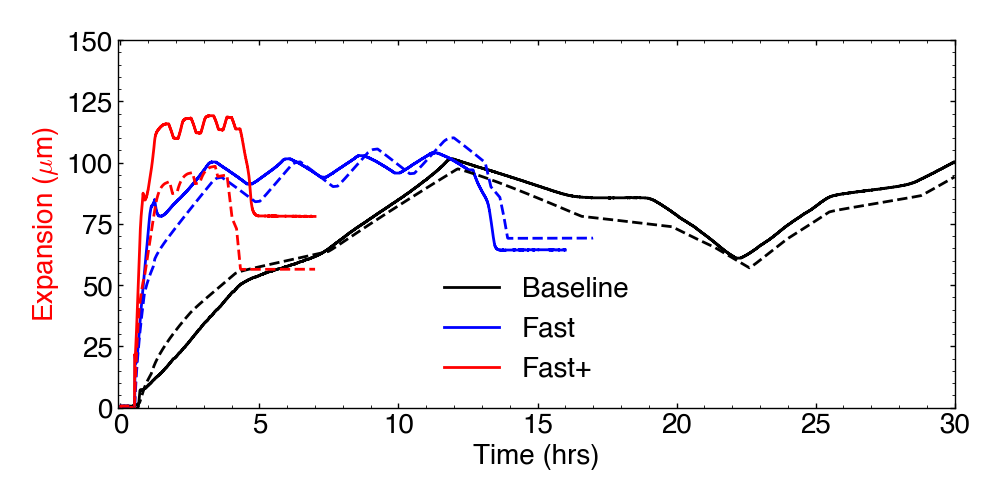

In [16]:

plt.figure(figsize=(10,5))
ax1 = plt.gca()

XLIM = (-0.1, 30)
# The voltage plot
ax1.plot(expt1['arbin_time']/3600, expt1['arbin_voltage'], color='k', label='Base')
ax1.plot(expt3['arbin_time']/3600, expt3['arbin_voltage'], color='b', label='Fast')
ax1.plot(expt4['arbin_time']/3600, expt4['arbin_voltage'], color='r', label='Fast+')
ax1.plot(df_sim1['t']/3600, df_sim1['vt'], color='k', ls='--', label='')
ax1.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, df_sim2[df_sim2['t'] < 17*3600]['vt'], color='b', ls='--', label='')
ax1.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, df_sim3[df_sim3['t'] < 7*3600]['vt'], color='r', ls='--', label='')
ax1.set_xlabel('Time (hrs)')
ax1.set_ylabel('Voltage (V)')
ax1.set_ylim(bottom=0)
ax1.legend()
ax1.grid(False)
ax1.set_xlim(XLIM)


plt.figure(figsize=(10,5))
ax2 = plt.gca()

# The voltage plot
ax2.plot(expt1['arbin_time']/3600, expt1['arbin_current'], color='k', label='Base')
ax2.plot(expt3['arbin_time']/3600, expt3['arbin_current'], color='b', label='Fast')
ax2.plot(expt4['arbin_time']/3600, expt4['arbin_current'], color='r', label='Fast+')
ax2.plot(df_sim1['t']/3600, df_sim1['i_app'], color='k', ls='--', label='')
ax2.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, df_sim2[df_sim2['t'] < 17*3600]['i_app'], color='b', ls='--', label='')
ax2.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, df_sim3[df_sim3['t'] < 7*3600]['i_app'], color='r', ls='--', label='')
ax2.set_xlabel('Time (hrs)')
ax2.set_ylabel('Current (A)')
ax2.legend()
ax2.grid(False)
ax2.set_xlim(XLIM)

plt.figure(figsize=(10,5))
# The expansion plot
ax3 = plt.gca()
ax3.plot(expt1['daq_time']/3600, expt1['daq_strain'], color='k', label='Baseline')
ax3.plot(expt3['daq_time']/3600, expt3['daq_strain'], color='b', label='Fast')
ax3.plot(expt4['daq_time']/3600, expt4['daq_strain'], color='r', label='Fast+')
ax3.plot(df_sim1['t']/3600, (df_sim1['expansion_irrev'] + df_sim1['expansion_rev'])*1e6, color='k', ls='--', label='')
ax3.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, (df_sim2[df_sim2['t'] < 17*3600]['expansion_rev'] + df_sim2[df_sim2['t'] < 17*3600]['expansion_irrev'])*1e6, color='b', ls='--', label='')
ax3.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, (df_sim3[df_sim3['t'] < 7*3600]['expansion_rev'] + df_sim3[df_sim3['t'] < 7*3600]['expansion_irrev'])*1e6, color='r', ls='--', label='')
ax3.legend()
ax3.set_ylabel(r'Expansion ($\mu$m)')
ax3.yaxis.label.set_color('red')
ax3.set_ylim(bottom=0, top=150)
ax3.set_xlim(XLIM)
ax3.set_xlabel('Time (hrs)')
ax3.grid(False)




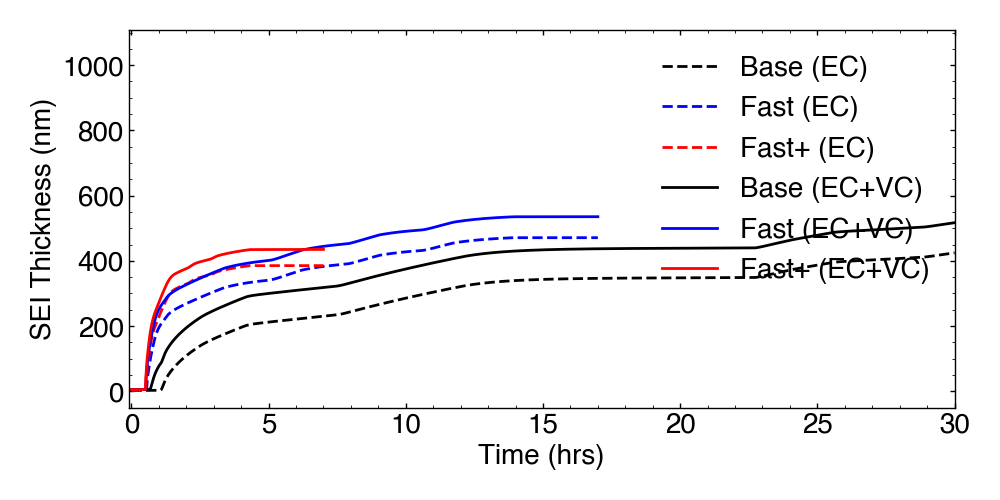

In [24]:


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['delta_sei1']*1e9, color='k', ls='--', label='Base (EC)')
ax4.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, df_sim2[df_sim2['t'] < 17*3600]['delta_sei1']*1e9, ls='--', color='b', label='Fast (EC)')
ax4.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, df_sim3[df_sim3['t'] < 7*3600]['delta_sei1']*1e9, ls='--', color='r', label='Fast+ (EC)')
ax4.plot(df_sim1['t']/3600, (df_sim1['delta_sei1'] + df_sim1['delta_sei2'])*1e9, color='k', ls='-', label='Base (EC+VC)')
ax4.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, (df_sim2[df_sim2['t'] < 17*3600]['delta_sei1'] + df_sim2[df_sim2['t'] < 17*3600]['delta_sei2'])*1e9, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, (df_sim3[df_sim3['t'] < 7*3600]['delta_sei1'] + df_sim3[df_sim3['t'] < 7*3600]['delta_sei2'])*1e9, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel('SEI Thickness (nm)')
ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)
ax2 = plt.gca()

In [19]:
# Create a table comparing SEI growth across different protocols
df_result = pd.DataFrame()

# Create column headers for different time points
time_points = ['2 hrs', 'After Formation Cycles', 'After RPT and Aging', 'After 20 Cycles', 'After 300 hours']

protocols = []
total_sei = []
vc_pcts = []
D_sei1 = []
D_sei2 = []

 # Base formation (sim1)
for t in [2*3600, sim1_time1*3600, sim1_time2*3600, sim1_time3*3600, 300*3600]:
    q_sei = df_sim1[df_sim1['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim1[df_sim1['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Base')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim1[df_sim1['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim1[df_sim1['t'] <= t]['D_sei2'].iloc[-1])

# Fast formation (sim2)
for t in [2*3600, sim2_time1*3600, sim2_time2*3600, sim2_time3*3600, 300*3600]:
    q_sei = df_sim2[df_sim2['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim2[df_sim2['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim2[df_sim2['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim2[df_sim2['t'] <= t]['D_sei2'].iloc[-1])

# Fast+ formation (sim3)
for t in [2*3600, sim3_time1*3600, sim3_time2*3600, sim3_time3*3600, 300*3600]:
    q_sei = df_sim3[df_sim3['t'] <= t]['q_sei'].iloc[-1]
    q_sei2 = df_sim3[df_sim3['t'] <= t]['q_sei2'].iloc[-1]
    protocols.append('Fast+')
    total_sei.append(q_sei)
    vc_pcts.append(q_sei2/q_sei * 100)
    D_sei1.append(df_sim3[df_sim3['t'] <= t]['D_sei1'].iloc[-1])
    D_sei2.append(df_sim3[df_sim3['t'] <= t]['D_sei2'].iloc[-1])


df_result = pd.DataFrame({
    'Protocol': protocols,
    'Time Point': time_points * 3,
    'Total SEI (Ah)': total_sei,
    'VC SEI %': vc_pcts,
    'D_sei1': D_sei1,
    'D_sei2': D_sei2
})


print(df_result.to_string(index=False))

Protocol             Time Point  Total SEI (Ah)  VC SEI %       D_sei1       D_sei2
    Base                  2 hrs        0.111643 56.374311 9.548833e-20 9.548833e-20
    Base After Formation Cycles        0.330934 21.252287 5.324344e-20 5.324344e-20
    Base    After RPT and Aging        0.443739 16.707639 5.036051e-20 5.036051e-20
    Base        After 20 Cycles        0.512552 15.443386 4.961320e-20 4.961320e-20
    Base        After 300 hours        0.441732 16.768274 5.039692e-20 5.039692e-20
    Fast                  2 hrs        0.164138 25.702628 5.640542e-20 5.640542e-20
    Fast After Formation Cycles        0.261448 17.878701 5.107310e-20 5.107310e-20
    Fast    After RPT and Aging        0.394948 13.384242 4.844239e-20 4.844239e-20
    Fast        After 20 Cycles        0.466611 12.691534 4.806084e-20 4.806084e-20
    Fast        After 300 hours        0.394576 13.392552 4.844700e-20 4.844700e-20
   Fast+                  2 hrs        0.183375 18.493594 5.145540e-20 5.145

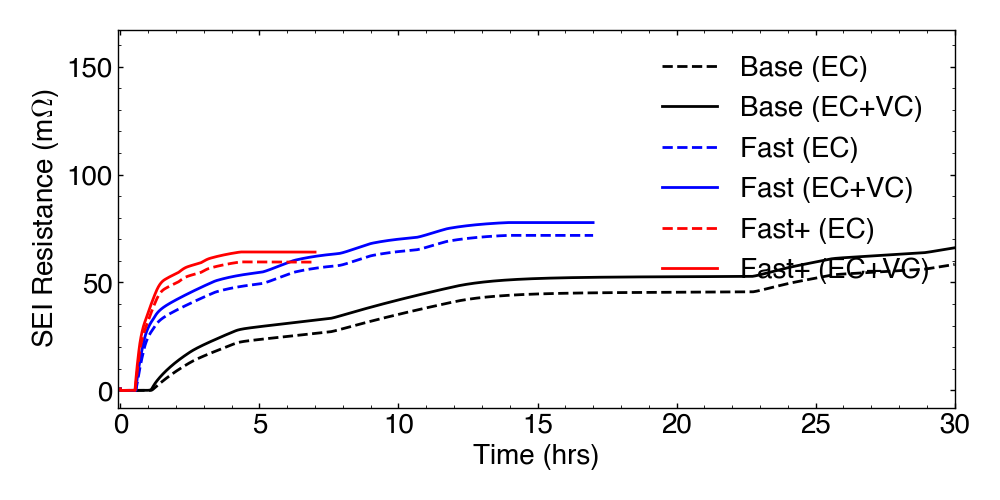

In [23]:


plt.figure(figsize=(10,5))
ax4 = plt.gca()
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei1']*1000, color='k', label='Base (EC)', ls='--')
ax4.plot(df_sim1['t']/3600, df_sim1['R_sei']*1000, color='k', label='Base (EC+VC)', ls='-')
ax4.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, df_sim2[df_sim2['t'] < 17*3600]['R_sei1']*1000, color='b', ls='--', label='Fast (EC)')
ax4.plot(df_sim2[df_sim2['t'] < 17*3600]['t']/3600, df_sim2[df_sim2['t'] < 17*3600]['R_sei']*1000, color='b', ls='-', label='Fast (EC+VC)')
ax4.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, df_sim3[df_sim3['t'] < 7*3600]['R_sei1']*1000, color='r', ls='--', label='Fast+ (EC)')
ax4.plot(df_sim3[df_sim3['t'] < 7*3600]['t']/3600, df_sim3[df_sim3['t'] < 7*3600]['R_sei']*1000, color='r', ls='-', label='Fast+ (EC+VC)')
ax4.legend()
ax4.set_ylabel(r'SEI Resistance (m$\Omega$)')

ax4.set_xlim(XLIM)
ax4.set_xlabel('Time (hrs)')
ax4.grid(False)